<a href="https://colab.research.google.com/github/fizajamil-dev/Classification_model_training/blob/main/Classification_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Import Dataset**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import os

file_path = 'D5_Repeat_Students.csv'

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("To resolve this, please upload the file to your Colab environment:")
    print("1. Click the 'Files' icon (folder icon) on the left sidebar.")
    print("2. Click the 'Upload to session storage' icon (page with an arrow pointing up).")
    print("3. Select and upload your 'D5_Repeat_Students.csv' file.")
    print("After uploading, run this cell again.")
else:
    df = pd.read_csv(file_path)
    print("File loaded successfully. First 5 rows:")
    print(df.head())

File loaded successfully. First 5 rows:
  StudentID  Age  Gender ParentEducation  StudyHoursPerWeek  AttendanceRate  \
0     E5001   26    Male        Bachelor                 20            89.3   
1     E5002   22  Female         Primary                  4            48.6   
2     E5003   23    Male       Secondary                  5            51.6   
3     E5004   20    Male         Primary                  8            73.1   
4     E5005   27  Female        Bachelor                  3            50.2   

   PreviousGPA InternetAccess ExtracurricularActivities  SleepHours  \
0          2.0            Yes                        No           8   
1          1.7            Yes                       Yes           5   
2          2.1            Yes                        No           6   
3          3.5             No                       Yes           6   
4          2.1            Yes                        No           7   

  TuitionSupport  MathScore  EnglishScore  ScienceScore Fi

## Total Numbers of records

In [ ]:
print("Total Records:", df.shape[0])
print("Total Columns:", df.shape[1])

Total Records: 120
Total Columns: 15


In [ ]:
print("Total Records =", df.shape[0])
print("Total Columns =", df.shape[1])

print("\nColumns Names:")
print(df.columns.tolist())

Total Records = 120
Total Columns = 15

Columns Names:
['StudentID', 'Age', 'Gender', 'ParentEducation', 'StudyHoursPerWeek', 'AttendanceRate', 'PreviousGPA', 'InternetAccess', 'ExtracurricularActivities', 'SleepHours', 'TuitionSupport', 'MathScore', 'EnglishScore', 'ScienceScore', 'FinalResult']


In [ ]:
print(df.isnull().sum())

StudentID                    0
Age                          0
Gender                       0
ParentEducation              0
StudyHoursPerWeek            0
AttendanceRate               0
PreviousGPA                  0
InternetAccess               0
ExtracurricularActivities    0
SleepHours                   0
TuitionSupport               7
MathScore                    0
EnglishScore                 0
ScienceScore                 0
FinalResult                  0
dtype: int64


In [ ]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

StudentID                    0
Age                          0
Gender                       0
ParentEducation              0
StudyHoursPerWeek            0
AttendanceRate               0
PreviousGPA                  0
InternetAccess               0
ExtracurricularActivities    0
SleepHours                   0
TuitionSupport               0
MathScore                    0
EnglishScore                 0
ScienceScore                 0
FinalResult                  0
dtype: int64


/tmp/ipykernel_1048/4059232932.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.drop("StudentID", axis=1, inplace=True)

df.head()

,Age,Gender,ParentEducation,StudyHoursPerWeek,AttendanceRate,PreviousGPA,InternetAccess,ExtracurricularActivities,SleepHours,TuitionSupport,MathScore,EnglishScore,ScienceScore,FinalResult
0,26,Male,Bachelor,20,89.3,2.0,Yes,No,8,Yes,52,52,56,Pass
1,22,Female,Primary,4,48.6,1.7,Yes,Yes,5,No,28,34,30,Fail
2,23,Male,Secondary,5,51.6,2.1,Yes,No,6,No,44,40,45,Fail
3,20,Male,Primary,8,73.1,3.5,No,Yes,6,No,71,72,79,Pass
4,27,Female,Bachelor,3,50.2,2.1,Yes,No,7,No,43,43,35,Fail


In [ ]:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index(['Gender', 'ParentEducation', 'InternetAccess',
       'ExtracurricularActivities', 'TuitionSupport', 'FinalResult'],
      dtype='object')


In [ ]:
le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,ParentEducation,StudyHoursPerWeek,AttendanceRate,PreviousGPA,InternetAccess,ExtracurricularActivities,SleepHours,TuitionSupport,MathScore,EnglishScore,ScienceScore,FinalResult
0,26,1,0,20,89.3,2.0,1,0,8,1,52,52,56,1
1,22,0,2,4,48.6,1.7,1,1,5,0,28,34,30,0
2,23,1,3,5,51.6,2.1,1,0,6,0,44,40,45,0
3,20,1,2,8,73.1,3.5,0,1,6,0,71,72,79,1
4,27,0,0,3,50.2,2.1,1,0,7,0,43,43,35,0


In [ ]:
X = df.drop("FinalResult", axis=1)

y = df["FinalResult"]

print("X Shape =", X.shape)
print("y Shape =", y.shape)

X Shape = (120, 13)
y Shape = (120,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.35,
    random_state=42
)

print("Training Records =", len(X_train))
print("Testing Records =", len(X_test))

Training Records = 78
Testing Records = 42


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.9761904761904762


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.95      0.98        22

    accuracy                           0.98        42
   macro avg       0.98      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)

print(cm)

[[20  0]
 [ 1 21]]


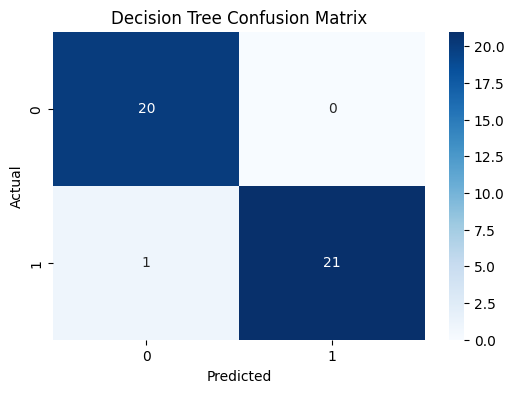

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

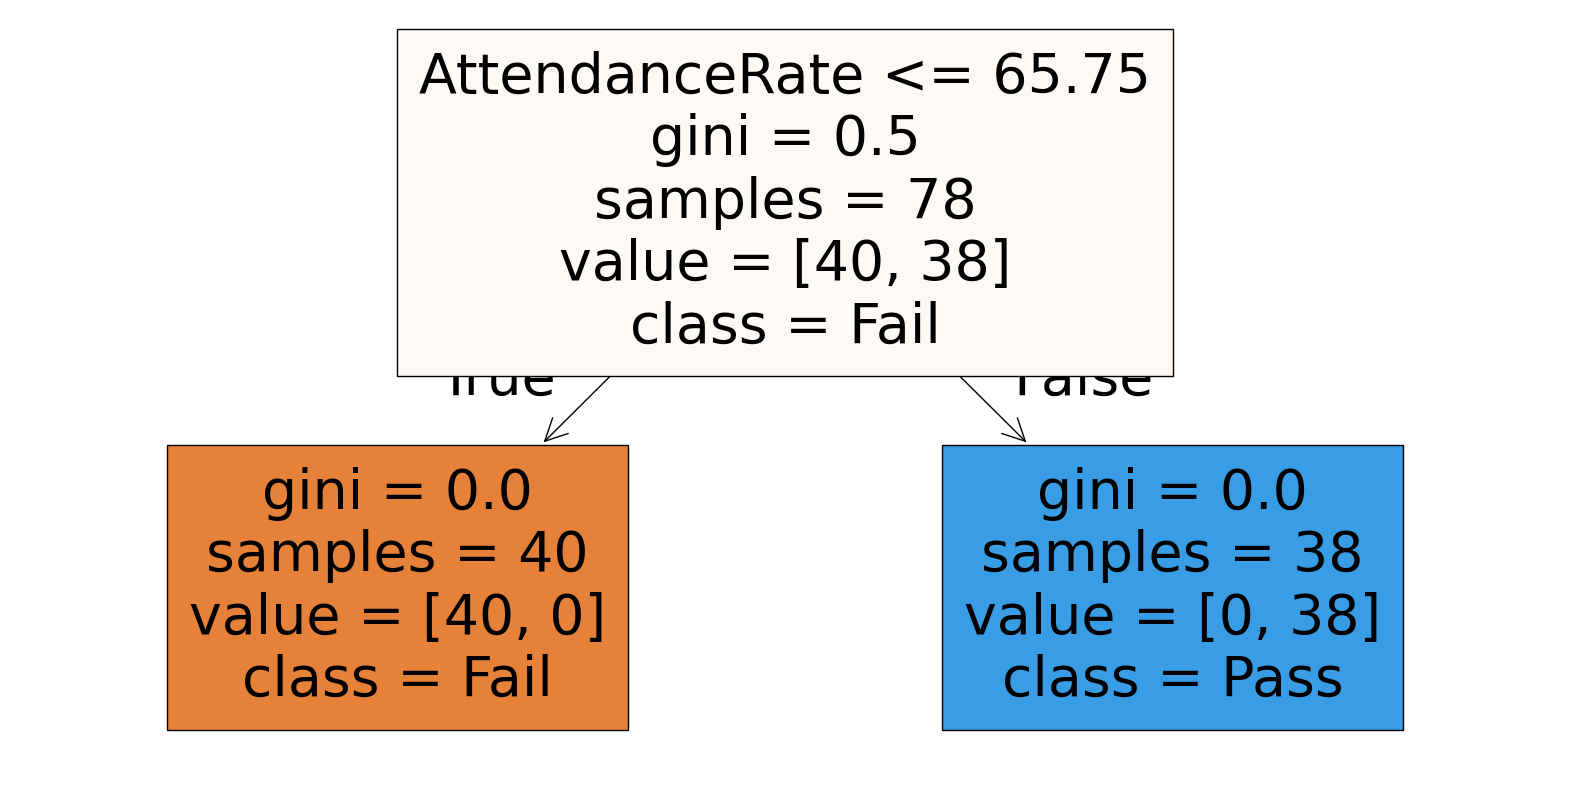

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    max_depth=3,
    filled=True,
    feature_names=X.columns,
    class_names=['Fail','Pass']
)

plt.show()

# Random Forest Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [ ]:
print("Decision Tree Accuracy =", accuracy)
print("Random Forest Accuracy =", rf_accuracy)

if rf_accuracy > accuracy:
    print("Random Forest performed better.")
elif accuracy > rf_accuracy:
    print("Decision Tree performed better.")
else:
    print("Both algorithms performed equally.")

Decision Tree Accuracy = 0.9761904761904762
Random Forest Accuracy = 1.0
Random Forest performed better.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        22

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42



In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[20  0]
 [ 0 22]]


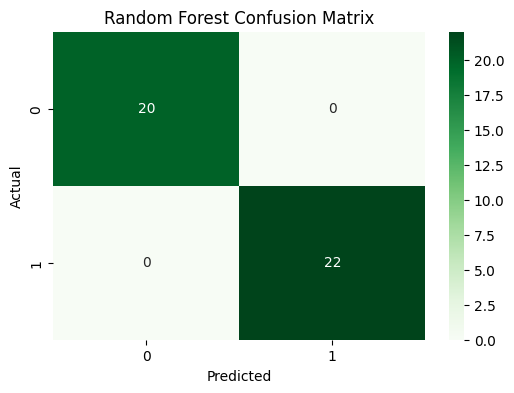

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

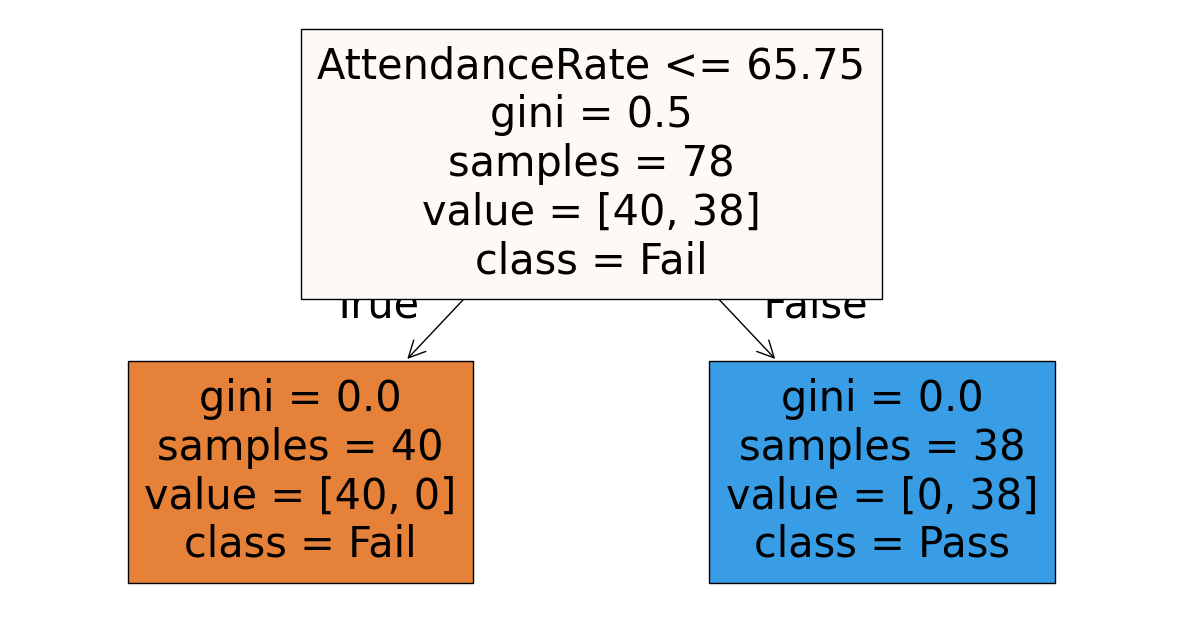

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

plot_tree(
    dt_model,
    max_depth=3,
    filled=True,
    feature_names=X.columns,
    class_names=['Fail','Pass']
)

plt.show()

In [ ]:
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Decision Tree Accuracy =", accuracy)
print("Random Forest Accuracy =", rf_accuracy)

if rf_accuracy > accuracy:
    print("Random Forest performed better.")
elif accuracy > rf_accuracy:
    print("Decision Tree performed better.")
else:
    print("Both algorithms performed equally.")

Decision Tree Accuracy = 0.9761904761904762
Random Forest Accuracy = 1.0
Random Forest performed better.
